# Project-2 V2 — Final Jupyter Live Camera Demo

This notebook is **self-contained**. It embeds the exact known-good V2 bitstream/HWH and runtime model constants from the Vitis setup that reproduced **91.5% accuracy on 1000 CIFAR-10 test images**.

Run the cells from top to bottom. The camera stays open continuously, a background thread always keeps the latest frame, and the main loop performs preprocessing → param 530 → R/G/B upload → V2 inference → live display.

Stop the live demo with **Kernel → Interrupt** (or the notebook stop button).

## 1. Restore embedded bitstream / HWH / model

In [1]:

import base64, zlib, hashlib
from pathlib import Path

ASSET_DIR = Path(".v2_live_assets")
ASSET_DIR.mkdir(exist_ok=True)

BIT = ASSET_DIR / "v2_live.bit"
HWH = ASSET_DIR / "v2_live.hwh"
MODEL = ASSET_DIR / "v2_live_model.npz"

BIT_SHA256 = "2b04c3941de938359afba9694ac26b5e5d48da773da1161a67dbe16f796f0aad"
HWH_SHA256 = "6207eab1bc0d4629c7b908b7e4a0b3d0d7f73f3b0133180db9762bca3d013031"
MODEL_SHA256 = "0568d1b89bf5d1d8007dcc2ecb9c4efecacdbfd0d7b4400b1bf848c7d9e45b03"

BIT_PAYLOAD = (
'...'
)
HWH_PAYLOAD = (
'eNrtfdty2zjW7v08hUpdtWv+i9gEKcl2Jp4piqJt/hFFhqTMZP6aYsm2klbFltWSEqb71fbFfqT9ChsAJfEgHoAFUJma3V0d26L4'
'fcQHLIALp4X/+7//z7t//Hh57nyfrzeL1+V1F50p3c58+fj6tFh+ue5Og5s3l93OZjtbPs2eX5fz6+7ytdv5x9//8s4cvfc/+YFp'
'd8xReG96vuVMCF7tdgLLNv1At93rbvBt3vHnq07nsqMob9HVW03rqIo66HburXt95ByA+GL/TD1D3b//5S+dzruE2prcOB3dM+6u'
'u3/8vvyt2xk6uje67m6/PZ89vr6cbeO3K3z9zR/q29VsvcUPIMkfmfeWYV53L/5QVPxxotv4w9N8s/iyjHDqXN14r9/iS4/PX3oK'
'vsF3TXN06+kjfO0N6p4nKTA/BqY30ceu4wX+3/EVfI383RlZ3nXXcrqdsXkTYMW9/SNGIy+aPT2tux3Pur3DXxFu69byr7vflk/z'
'z/RTcutq/fo432xwHkeb3zfb+ctFpEQErxN88jT8PMOZTEwjwBnk76/lrnasCc7niVHBiLXiBCcJo8TnB+bzI+p35+TmGqFqVufD'
'TETlcLb82prSAzlQbSrycbaJlvzqDN3HsDakJcziur5mZD0+f2US9fy1LVGUWYaoFUBUW5JkCJoDbO+92Y4izCuuCFadWqtNApUp'
'aRK1rLqnF5EmcWS3ohHTiilEOYm/CUn80I7EDzIL8TdqoyIi2zLXhFmu1JWg1LaEirc1r09bfkXOKGhFEeEVVrSGeSNea96IJ8cb'
'Wc838y1R5jpj3bOCT9ddHZPcm9HYCQ9615stk016fjBsxyops7DaeA4pxNBsRxThFZJ0Y300R5HlRNjhjr6vAdLuvUkr0givTGkr'
'iDS3JWmu2Hugrx2JfFm8Qt8FNiaWLZNwyim91Sba9waYFbl+ZIzfSxe1o5Wma/W6fuAWhkmHbSijvNKkbXB7z6/Nb6X1PxCzqXt3'
'Xhg6yo4mWRP8+0Y3zD1sOPUP1zr4Q32T0u2M9EAPrVFwd929zLxXup3gk4v/tCZWYOmB46W54Ooevgs/Yne3/tGKdG9oBZ5O0h/5'
'xp1pm93OvT6e4q+DXJehCB5OcU5EY3NyG9wdIJc1AEOfRCNzOL093P159ryZ1yL8aKwH5sT4dMAg1AAIseNgcsL8yJzow7E5Oty/'
'XX+rTdnUDxw7wpcDv+Y2UkSRrfvvefkpkBYuU9bapu14n2hymu8i5nFgNRzbdSbmpFYGBkY6ed3YuntAek4YGc54ak+ioT55XwP3'
'x05wgPnYkp/rpJMhY9f0LGeE63FafmpfyYJwfcKJyVbm3aXO2Lm1DH2MrZtWBvfuk598PgzKntehhnoR8zCrRxCjmxRByYBhPe69'
'eYT6Om/ClDzqa/OTIrcEtWpAlclqVIXbjALm6aUB8eEI8VsToiRpSX+9EeeW4RpygnTaCijSqazFeGVWsW62Cs/0zaAEuesa1WJD'
'8xhIexmZ11W+5rw7z751+F9E+xd18cXN8RJieC0wVPa9n59Rf9QhOW8mcGsIGoyE+KllYOJO1wJ3vmAZduexNsGpw1WBp55hE0Hi'
'1FQwJA4Yhwmlbk/WxyFf2M5oOj44PMmnznCUzslFsx+LaPPySFyu4SixIX+IX5uG45meeW/tpgixwzPyrHvTwxz0LebhtvRmOh4n'
'NnW+o+l27rITkpg09fMOt1hu8hwsA3/YuwL4/m4Hsxtj3fd3X+KPya2bl9l6+/i6XM4f6ViEHVWJuB9P7q+7PxbPi+UPMlH5drF6'
'm0XTecpD1o4cY2qTl3GmvPbXOr4z9UjCf91uV2/Pz+M4Pkt5zx+/LN48LJbnT6+Pm/PFCv/6x+N19kl/+379HUXK356uV1/U3sWb'
'7Hdnq6fP2RI+Skdaa3O1sFCV73CbR9uv9LWdN73iq35sRwcHJCLXDsCSvKxj0kf3pFSxy+A52HkILDN1HeqRxuvL6nU5X26jyexl'
'Dn0+Ua5T6RNG7ZOpTaq9z3G7bXHc7LPe7BPv37xNXWV9il1b3CEwamHm6H2U1JwDkNSRbDNxZDLvMjPohb7fYUDiMIduK0pEOiiz'
'NeNM+r6kCsD0cVX9wOq+4Mvvi1Xa+9tgYvKQHfF5jvm8vIuZ6elWKVaPFeN37RakmALbUEyJBRVbx0LX89nT7xz6kvvbEJgwi5dp'
'UeH32fPiiUNhcn8bChNmWVZ7XE9jaD2N26qnccv1NIbW07itehq3U09jznoat1ZP45bqacxZT+PW6mksq57mFT7wFeFDWyX4IKUA'
'rcOauxKdmxWgTia4VvRuVtJr5AOfuT60Za0PUozVOl5jsk/5+mm2nQGKM8HJF5zwyq6cnH5Qa27QuuXKuQZWznVLlXPdSuXk9Pla'
'c/kke3zHlTMGVs64pcoZy6icR8XJ6fy05vtIc30KK8AOCd9sySQyf2lSXAt6Ka/sppbT0WvNz4vbenP60HETX964Se16DvqQWxc/'
'zKNTdNLfNqmQh290sRggCxLkKfKAzqPLs4PjTHicPf46B2VCgjxFJhi6cWfKs4QSUyB1HpAFgnWfVb81atMCnudLkHiCO4X6sTlp'
'sxV4fn38CtNPgCfJAMd4Ly0H1OMc4Byn8uWNJ7PmgOs5rTaCv71uQBlAcKfQ/8Hxpbk6Pufwui9xeJ1Vr2fqo09tmvxm8QfspUeB'
'p8gC3/qnKa2z4nNOOPgSJxxYBd/rY5nvueOWPoZ6vPGpPN6wZY83Bnu88ck83rBtjzcGe7zxyTzesHWPN4Z5vPFpGoOwVY83Bnq8'
'8Yk83rBdjzeGerzxqTzesGWPN4Z6vPGpPN6wZY83Bnq88Yk83rAVjzfm9Hjjk3m8Ydsebwz1eONTebxhOx5vzOnxxifzeEMpHq9T'
'/ZJ/AL3jH06ifijlDV/Qy1e9H05Vu4dSKrdT+UbnXdTgS1vUwKzfd6W35g98FfvhVPV6KLdaH3dkeRc9+NIWPbBlgEe2p7XYrMEG'
'608zVu9JKfmC3ufZZsuuk959AqVjXUo3vaCVrwk/2ZCk13ITvgY24esTNeFeK00452jkyQYjWx+LjIFNeHyiJjyU0YTXDD/BRp9O'
'M/gUtuCZxlxNeHyiJjyU0YQfVWrOTvbJ+tiSu9hHYyq8C6R8aQukGPX7QTbwhizL5mvCT9a7Fu5cG+P3N575YUriRCQBBuh/3UI+'
'zLIxYxiiSd5gXrKzT2ktD9InyCrrGd1ezhd4C3+KVhuiGCmKHa3m68Xq1/l69hzt2UT059n3yksewp8Fyad0U2J2+3IWxLEN/mCV'
'uagsWnGQbr8r3h/r92bZ3uDldr7+PHucv8W16uUltze4YtsridyVCxOCH3pej/GmvllEKU2gEAAaAjDEtEeOrVuT4624pVmfrXD1'
'1CUxVRozizQQ0d0/c2FIklaiHkf2AyeDIqWbcKsQdGKUB5HMIvIg6MQLD4DOU/AAyMA+z/2eeYurK7OFUAh31ibvRlaENSoYCmoy'
'FNxymV4Q3VsusxBb/xiVBlFCgwYk2d9NfJ3ImQakwRxZk9uyOEH14OCO/ErLqscATIIrQR+boHmf6+LyS21cOWvKV2KwjuGM0w3t'
'Hy2tAUMzJEkeiSiRBjk6XG8ioG3d0ApwhSF/fApMZkOANMj+1KVvsWiieyQSU77paEKHAqllehMcRWypCNHkFYM0FRahnzcz7JSX'
'USRLWhg4ds1oGUeyIoSBA/uipQTFRf7laLIgoBROViSw4GmzXkpApvQZGJJ2vozheE9xOQNt+MsIyJQyAz7pvpUylGx9KeegU4yl'
'FHSWk4Eh6VaUUpRs2SjlCCutOma06rDaqmNWqw6rrTpmteqwIititnyosuqYzarDSquOGa06rLTqmNGqwyqrjtmsOqy26pjVqsNK'
'q44ZrTqstuqY0aqH5fgHJmxlJjww5sHOmS4lKG7hLMVXZsADo/5k0quEoGRLcCm+/PFM74dkKqYMTQcSm/GV+c/asnpV+b9my//q'
'ZpW1VQ2r8j9my/+KpoypJQur8j9my//qRoC1Ddj1X0oIjndJluIr8798I2JJzL2SUIE14ySFjZQVAyN2fmDExtlsei2NjPT/HBj5'
'zxgYUbgHRhTegRGl7YER5T9kYEQ55bjITxkWQT9pWASdYFikN2YY2fhzaOTfY2jE5h4aKXZ+bO4u/ZHfYvN3yY88D1u8Q21zd6gr'
'84K5I1idF+wdueq8YO6GVSYD3JWyRbtStmhXyubsSlXmAbg7Y4t2Z2zR7ozN2Z2pzANwl8IW7VLYUroU+auHKNNJtOh86OhCVOhc'
'COh92JXqCND7O/YBoMmpA+6d6enj6jjQ2XsO4aAJUUmn5dtmvn5LvqsI8pzGyiXNm+n7Q+KDZvMne72jGzg3cBKIhF3mHMLJ7PtT'
'6/kXLMjTJ+RU255yNeh2pj494hZ/s8Bdg9xZqKWPZQv1bBwWfDT1tGqgjR0P7mjNSZE2BGsuCV2cKdb6pA+x05W8jPbv9x895bjn'
'U4K8s27vypA3NzfgqMmHBRyH6JH/0YtVCpFnC/GYf0qE6EMU+d3ypBofTWB9Tqr0/6N1Og0b3wqxqX9KtOzK0pcRhtc5Vnr6cNmV'
'CmVFiixKPH287EqJciO0HTdbPzFgdpXmWFKzVVVXf2LE7ErJ7dTVnxAyu1JhS3X1J8TMrpQoq67mJZ4+aHaFwAe5sT9RidCfFDW7'
'WrB4ZN6jWnn6sNlV8toKzZuPU/0z4mZXKF5Ljc1bCFh9wsDZVfJarqA/L3J2teAWKujpQ2dXyWsrPG8+VvXPiJ1doTiWGtm+ELT6'
'hMGzq+TJDW2vHQn9adGzqwTLCJ991OCePnx2lTxoBRXb/sO2rOUwKtv+fp8/V7W0sKrlzzUsf65h+Tdcw4J+zhoW9Ocalj/XsMhZ'
'w1J3hCbbGpa6IykZ17DUHvrIuIal9lhFtjUsdccUsq1hqTv2j3ENS+3BeoxrWGqPrmNbw1J3OhzTGpaa49bY1rDUnWjGtIal5oQw'
'tjUsdYdwMa1hqTnVim0NS93BUUxrWGoOYmJbw1J31hHTGpaaw4PY1rDUn8/TyhqWyY11O/WSxSaBNzWLp51f5ta1lE+2Z1a59M/6'
'3cbJ+eY1L/iTS06C18fkFX1Y63JMV37I+fF9b0nCWjvq/Ph55MDzfqTRA8+VS/VNeseb3R2Sjj03opFdeGP2GhaDjD743AjOlTKR'
'aVtOdOviH3ngoOlR5iTBmhMzUFiPUc+hEDfK/e9Av+VGBR6uXcyoQ88Ru1M3BxStcWxAlAMmNYMNqYKRGjeSBMfBGYRrrHVjkeoc'
'BR9ZT6UnaCSAtibGeDoyI91wSeFMcCf2zqzqk9bgacES5Temxw72PkQ3qpt38UeWZxpBA5JaoGfZFllLkw6tNFWUNBhR0m5GuM0N'
'LAP3wfA7gjnZKUtD2IlabNL1EqBAUkQgoRSARZAuKCl6/Mr18A8X92KZbdbVjff6rRmRzwfQ4/OXXuOSPte/iHwL59R9upDQw291'
'OgDZtAYyWTyJ68luhO5eT7u1GmJHhyLoo5zWmKClxjpghCIo9A4/tWRUr/F9lqLBD0ZCDxZQrAo9WIU/WBN6sMb/4GyTj198jvE+'
'Gplj/RN7I5BjuLFunCjZN3/AXzIRULd9oo8L6Wd7umu55tiamAVw05NxHaY5N3EmvmlMPXanhiBH5o0+HQe0Rh+1BiwEmfhljI1m'
'FoW4nnVofACobAp5UJAU3oGedQd8lgpCaYwogknsk1Zqc3RLjCbAjpHD7F41rLwvn62ppXSNENsBNlt3GqX90IhMwtiZrcWDvnLG'
'sMJ+z2boE6WOTtXOLpWrPisXkshVR4W4RI4Mq4nsaoAaHNg9Ge3n1dKpfZ7E0R6gPK037q0uM3mET3LyVLl0mjw6SzXqyPpsLK6h'
'u7X1QOFK1AfftSTS+SPSfasTycVmG/Kyv0EoH1ngWlOJ2RYEhpIMh9Sm8PJMI/8NuDhRC5yqXE7UgnbUgnbUgnYJTcJU94L6RHEZ'
'49Qf1pbFgJkGSaAJR4GsDMe+DRnJ8/SAjo2SEZY0NW/Vt4iJot49aqbwbHc8jozAw/jhyErHK9RmCdShKtn3aOKyvWQpX0pAf1jO'
'Af+/nrd/8+fP88ft39kIbj2X5mQhDxU+tEgKSnZw0jzI7eCsI8iUIk6L7xkHJvPHdr5ezp65eWC5UWNObxALBaoyiCtGg0DJD3hx'
'ICGDQBIMAlUZxBWjQSBJBoFEDQKJG0SNFMvp4MaHlwQ3UpbveKwjEtUMCM5Q8k7jpdjNL7OXBvFJyHPrI2tVYVEBq7BDVThUg0Id'
'z8RqrQ903J4nlyiQzPcAgAj6RAR6InEA8L/Bx97HiCwLpMEZ0rf34IKZgrzCj0xSS/wsJpLqOoodBLZKmmc5qqRqM4P3yQ8wVMwD'
'LYx/FNTgJplJTYHlSE1fBVIgjgxpHspB/atmlpFX5eEhFjD9V2pgSp/NwAjBneuNXS/6MDWnZoRvCqwgu/oXf/1X5b/O8S1/1dT/'
'YmWMAgdbDWYyiNl4lkMCH0Rj895MB7lRn4ltzMamMpFJsL88C6A2UQbHCxSaUdzv/j0cicFVMbgmAN8XIJk3JlyRAnLnyrmQRC5V'
'IpcmzkUXPcvKsJQMySRTZZLB8wxfLevtKApi83L2HCW9BXST/MfEsVtiL6X54luvRiGcK9YSDN+aNYqZEmH4i/HYHCcjxXTOKreo'
'h6sICSF2OYz3MtiSuZKKzu+QxRwShuRnpvNp424SGnTOzjrqBSMH6cLao+NhJcSLLySjr5Jk9DVGmope8JDFro+mnmB9xyOao1fp'
'JZgDcedrdW8cwFDSB1U69sNqw0jlmb4ZQNORgAvmccUErhwhMlgrCdr9BI7QJOCqOqLw4oVSUVFFDNYqguRUESQ4wFLFgUQ4gAUj'
'rYqg8iqicIEFrEOkhu6w+2hwaXf+cbv4Pu+MX2MeGt8ck6WyexL/19l63qHh2zqrxZKBKeq9jwLLNj2uXKRD0twIxImgc33YEeTK'
'4d10XhbG+jQVBtNgsMCzbhU4FMGhKhwK0ZptRJlKkO4T4LewPQxBYCO6JEGBQyFP5dmtUcRBnkd2lgBglmooMBgkkcTPt+lctSKE'
'hjybZ0tLFge1Hajh4E6RAoOBnka6wtYkAEB5dvvkcAHI5MjaCwAMamxQMwtHkLwMXbCd7aC8ac01T4gVwvmUXKPE9BD+9oi/KQK3'
'QuAGCND2uIELeYfsYZwJJEMxfAXl+QHEg8MwiHeDYSoMBvFq8lURsUI489y3DU4A95uB/6UAaNT523P+pjxfWRErhPcp/pD3If6Q'
'8xl874eb4qJI2GjDEc3RaEMPzMEzuXpTXI8JlyM6eFLFgTg5VDlyVAlyVAlyNDlyNAlyNAlyAPvLs1DeHeZZrCqA1SBYhn0ZTCRI'
'cDFI4w4MRg5NAseu1eIezTtgEf9A5AGrCmA1ADawIyOwcG8ONoec4pEgXhXEa0J4ZxooogRIlEAVJYDlgUiwiT2+MmxdjxleHn6O'
'BY8Ek4/Eko8Ek4/74xXzbDrLPBslSAPFcDcBBTxwGqTAwrXn/ICvmGPTWebYKEFVLiBOeH66lA0sMh9GRjCqjKDHYgSUgEx0WpMA'
'+Pg9GmgAlKOiAHssBUgJkh8CKRAuBeBMYgYLT37lhHuf0QaQkA0gCTZQOVHeZ7QBtPshkAJBG0ACNoCEbaB2d2ifiQE4G51CRSaj'
'U5bCXDRXPth0wd/Q0b1R5FK6A8/kdTlvJhAKYpVlAISxonCnai03C5b8X76Sm3GrwD6OFudOB2j4LYIlL08lSm7OrhhfLF+/bRnR'
'lpM70nF8b9iO39HOtHtGAnc6Hk/TsCTz5ezhef7ECPbHZniAbp4ZjJ3gkJhoJKwaCclGYN1ITDcS1o2EdCOoblVMtyqsWxXSrUJ1'
'a2K6NWHdmpBuDaq7V6qbFSsquickugcV3S8RzVzUfWHVfSHVfajqgYjqQYVqdHZ5z8ogonoAVX0hovpCWPWFkOoLqOpLEdWXwqov'
'hVRfQlVfiai+ElZ9JaT6CqpaRLRwWyYkGahYVQQkq4poOatCLqkKdUlVkYJWkbBqoaJWwWWtwh0UVRUWLeSNqlBvVNUERGvCooVc'
'URXqiqoCrqjaExYt5IqqUFdU7QuI7guLFvJEVagnqg4ERAs7oqqQI6pCHVH1QkC0sB+qCvmhKtQPVS+FutWqsCeqCnmiKtQTVa8E'
'ClvYEVWFHFEV6oiKDR0JjxwdvaqfFhsO1UDRmogvqgn7opqQL6pBfVENwe1bE3ZFNSFXVIO6opqYgWvC3qgm5I1qYBMXGxvVhB1S'
'Tcgh1aAOqdYT0y3sk2pCPqkG9Um1vphuYbdUE3JLNahbqgm4pZqwW6oJuaUa1C3VLsQKW9gz1YQ8Uw3qmWpinqkm7JlqQp6pBvVM'
'tSsx3cLOqSbknGpQ51TwHSbqnGpCzin0DdYTm73vCbunPSH3tAd1T3tis/c9YQ+1J+Sh9qAeak/MQ+0Je6g9IQ+1B/VQe2K1uyfs'
'ofaEPNQeuH6Leag9YQ+1J+Sh9qAeak/MQ+0Je6g9IQ+1B/VQeyJT+D1hF7Un5KL2oC5qT2DktCfsn/aE/NMe1D/tifmnPWH/tCfk'
'n/ag/mlPzD/tCfunPSH/tAf1TwVbclH/tCfkn0Lb8b6Yf9oX9k/7Qv5pH+qf9sX8076wf9oX8k/7UP+0rwq8v/rC3mlfyDvtQ73T'
'vph32hf2TvtC3mkf6p2KOWnCyyz7Qk0a1EUT8dAGopIHQpKh/pnICssLUckXQpKh3pnI8spLUcmXQpKhjpnI2sorUclCPhnUJXM9'
'y7YC6z5NNsN5pUkcONPM7HRLN0yTrbS/fPg2e+r4rtW5eZ5tfpX5sYyehL7qeCRGavJ14QeJCdRR9r/M5Xwr+9fUH0r56Y/qfpB7'
'EpX0Y5nUXLLYy9G3bifZMvyyWrz+j/KvX37brBZKtNlED7s/s5fx3yjzt5r5W/vX+Z0zHkXDPcPj89dfKOlFclf0+YFconFtky8Q'
'5k3+QPs/1P0f2r9+Wf/4ZUv+jwhs++OJJIP8QskvNfml/Yvesn3G99M718md6+TOdXLnOrlzndz5NNvO/qf3r1+eFutfNtvVL8sf'
'2+QaxtHfaPdb3f3GUEJN/+7vrg12vy+S7x5fnho5Eu2PT4nG3uVObO9q90d/nyF9DH55esT/Fq/NRbo/onu3e5QE3Q8ssqHT1l2O'
'fYQpz/EORg7w0QH0SOVA+1OX7iKd6J7nhNFw6vkBSEMS1EEoNUhShiKRDEWCEiRlKBLJ0Ik+GUXGJ2Ns+lEQ6TyRhPNQYwzHZuJb'
'IW6sqcOfC09yKJDk0OV9LIkjMLrk30GfBQO30FMK+kOEQCSEwMTxIsNXiI2ZDs8G/BToGiAYp10ecIEHelwIfByfPe1goUnj0nOX'
'A4KWA4KVAwKWA4KVAwKWA4KVAwKWA6nTutqHVaY9GFqhdxTEisDPJ2Dh5yOR5yPR59Ow3UKZcGCQkxIknBI5eQKKl3PEIJAS8k8A'
'LvqyOhQrqKXMoLmbywyWv83MgLkbzgw2FHkwdxN6wMLa0YPdixQVEigqJFJUSKCokEhRIYGiAr3ypvYh/A7+4U4Dn+Phzr3pedbI'
'JNHAcF/RGDtckYtc9SY5Ip4z+M8Oh0A4GoOTGzaydUOBAhEUqEKBGhTYgwL7UOAACryAAiN9SAYHAOjdQYowIMgKkiCP/LgkPCEI'
'B0onPe0SgKOHEUCBoJT6tgGCuZYCxIGSSc8EgAJhT/SHChDH/zzdeK/fmvSo2SR23sgc658yJy2cqRdXUBqUpRmAU6NmaJTLPpRG'
'y9JcqVw05CBccgjv+H3ClTlA+Q1m6yMxNpRjUwZibGqe7UqMTcuxaRozG7lywD4+f+kxRCF0Dd0VPxugyHJ0NECfm+IosCaLmBQO'
'j0tJD/UR6rDtGOhPYJ+RRJYcfnJ13ydxHgFJSOJ7DvXJeyW6d8Y4KbB56wwRqiJiWsLj+heRb0WemcbZdD1nNE3m4pvQ9C1L+vI3'
'Q1JRuAOnFvCFs3Yv2fHk3ctdGjk00CIOHL41uSWzVL5ALqQcxbOxyZnUAw4iXyQ7fF8sO/C71/QmuIruAxqbvp+JaXxjMJ77TsmE'
'G8EiC6ARLFLASliwFaUcSf6CjMMfJZHKjRF/+jPYwsN7F8xg1wn5jTILBtrkniJ04Y8PXZGni5gOwZN/xXxXSKn3+gx4VFHsCg8W'
'rB6JlD0SL3skUPZIuOzFQqoTPPkHfjzpy5YGxifhsBWFkaE0Lj1mYGnDk25xRRoQaxpQVRoQaxrE3yNFlqP3iKpwcwDOWSpSYKQ1'
'4mlPEh+DvkhGeqDnI5b/aF6ESMYr6AKHKHPwz0TnwSEgTgXiNCCuB8T1gbgBL07cqPMkgLPjCgwlcfd5KfIWzQAnI2EVx38MmFoY'
'QpA4voAp3hwa2lKnHEgoBUhCClShFKhCKag4AmXA1MwTAqHXLSFIxlXBEioPorlgtEQkZIlIgiUiIUtEEiwRCVkikmCJlYfxXDBa'
'IhK1RLQbqQdLkPByaOg4I16Go5fDYHA2oP/xMnG/I+gKWnKmje5NfdMjBAe4hnjwoRgesAo5BR+t+9UYwcAF5X71gvIBMxiJPBnB'
'n3yHk009XO4j9VI8OOV3Inl2h2WLpRyJpFwoz1XBlKsiKVdFUq4JplwTSbkGSXngWtOaZt78sZ2vl7Nnbh5AS1+kgIxwZg8MS9bu'
'JFNvPLscchw31o2DO7z/zIy3qZeMFMSHQIOhBVjgWCQAvsNTGlUwGaqUVGiiydDkpKMnmIyelFRcCqbiUjgVh2mWfLPBWkdE/NMd'
'g+WaY2tiFhLAWsN2KoBZEBiVQ5tM575SAnpceXUDarjTCH2EUUHa0DKeo3eKpp1p9D9mPiRPIpIkEUmWqMqTqEqSqMqUWDH83fv8'
'+TMbgVBtJwT0B7yyVs4B9BkrK5JXWZGkyookV1Ykr7IiSZUVSa6sSF5lRZIqK5JcWSvnqvqMlRWJVlaU/IBXVsEpqmSpaMU4KNO8'
'455hOoo8Pci476ivMsPpuqLpGJCHBTwwIxOWinFEpsnThEFk9UDCsFu7W1g20iMrCFCfiaNyWBuxFicSK04kWJxISnFWDgsj1uIU'
'q9wJw25FNVyG+NBwkeW46VW4OSBTh0UO3tnwqUWvRroR0FW/JA1RrrlT+2esjdaOi/Doo3tA6WYJxkAgWRIaEQuNDGc6CThGinMs'
'Y47uXA4IXzxfQcO7eL6ChnfxfAUN7+L5HM3UL4btGHSGiy0XiZGWzAUnkAyoKdHYnNwGd5FtpyMGF2dXfRDXfol7wpmajHLW62tA'
'Ss9xnVudLD8ujv5xFn7CiCQKRvIFI+mC1RLBMB7pYlXpYjVJYjX5YjXpYv3AIcsYoUKdcdl7AXGyhGOOCYoscmTeW4YZGTrOaStI'
'86KnXA06Nm4GN3x0H/zSxkxTz1APwFRR/rjbdqb0BxBCaaVP+MqaMQ2dIRXAVCF1MDi7UnoQPqlKxduvhKWqQl+doQvUhxBKlalJ'
'kVnZbiGknQ00CJ9UlWJ7BWvZuPcK1rJx7xWsZePeK5hnq2rYVH6eCvO4ujzrK4BkybSOqjZNueQnqmrSsMzLfh/AJ1OnjBatukG7'
'wt2iqz6ATqZEGa1ZTWOmaGdXFxcAPnkayR9lnTc+r8U00qGWEWtk5RwB9whgBlw2usFFQEa/osC03cze3fXL7LnzV+XNZf+/uLhs'
'03a8T1EudDO+3uFrlfBfwSQzsBn00H+r/YGNC8cz3yBOfSQ4Z5mPzMfiu6Y5iobWJKtLi5AyGNxwEQWebk2SVUnmJ2ihJyQ0bOht'
'bvAVwBJ6VkBq5705hvJEN3qY8f3PFE64p/uRnclarc9PkdbB3uXZFeKGj4BDMBjrAqFTP7Pg494zbwDN7K05Mcn4e+RPbVv3PvHs'
'NqHBOCqmcFWm0VFCUDEzprLMjFECobmQAkFxvHnAKCLZeg97fIIt7uUcsIGTgCh5rHpJZnG0KxaGyjl4jbEAK6c2NcYCFJz9KBDA'
'ChCVFyAXFjr3QhiS8DRgAgHz20FdZ6x72REY/XG7+D7vjBmOLkhZfHNsGukr0v91tp53aGz1zorh/DTSnpGVrzf60LOMyBpxFkWC'
'njgT3zSmHi/WcLAIbMoBL85zfNzV86zbW9Pjxu7EchXaLnoPjTnC+cCROZzecmNu9Ok4oJsNjvY5MFLYusIPQfwQlR+icULMj64+'
'GZlk+7sLhbp+5I9x4XvmreXj+3iLcV9DyMvfm7q8JktddsewOWGHGP6c1noIVc/5PNxTMyLsV04CMk3GCxbM4sMGGxAum0l8OATC'
'3QGfdwd+ngrE8VY3uiIYgtn1kUYkdhe+xwgcntaZ3hj51vgem072CKLmrmg4CsQXsxVIAMvYCgzcrk0BL7AAjjCRfwAHZ0W9B/ao'
'YObofWS5ufGDVEOKfHd+APqHa+Q0Dj/LjT93RpZHFsB0O2PzJsCqe93dk+iCjKendbfjEaeB5GgHuw+Wf939tnyaf6af9iJeH+eb'
'zWL5Jdr8vtnOXy4iJTrg0yfiZxrOZJKceeVnr+e+6VgTP9AnBjmIa75ZfFlGarR4WXU7JMFJwmaE+DzHfF5KjTMCgxpEq1nNw9ny'
'q6juA0cb2h9mMpSngg3dj5b8GhNYGwIfZ5toKVnjexOgEINa0fd1LlkdrABbKz/5xff89aDvcfd3kzp8WzuFF62ki8sUH7u8tkrv'
'q5zSS5pWLat0ZIs0qhjdht6nF4lqUU7uByG5H9qR+1tbhfvBF5Prt6R3I6fClksmNVdIdEu1mMiW3AiPPD8YHjSuN1smhRTUhkLq'
'OMvW6IwC/lIkoDYUvj5t5arzYJ6e15qnt5bv6d17E36FBCRb3431kY6hRbgfEH1fS5fpQmS6bcuU7BuF5pBfJgG1Ya3xXMhYjfF7'
'MsYwNSfGJxKUob/bYpHoPsi+ISuqyB5LHpcwBYkIL6PeZ0B6vqmOn5PPhiq+2Y9FtHl53FPMiBAm4Mvvi1X66I2iRISKHY9fTtFq'
'QzIGKYp94Hl+jef4m83vy8foiIvfVPNFRmeIlGhCnpbMNV13dYOcdh2NnZDnvZmnEynQ8nyY/9ju3p4LiZ5+/+Aa2eQizCki0NZa'
'qJf8kcZSq691EJ+vJ/9WdTh9grjlFzs8Gd1eMlneaAG75iHycf0m4Nl6JjpmVmhxCsyyVJeK3p1vDFD98I00Cq3ITqillXaZbkM3'
'7kyQ7sfZ46/zdnQn1NLKu7TAyZ5LgOrFUzuSF0/tlvOYbMIB6H2eL9sRTIhbrdHJQXoQya+PX1vSTJhliVbLRLueA2vF8IunpUaM'
'Mrdq2x8cH6T5t9dNO5IJsahnViaUrIj9xCFwPZ89/d6OxIS6VVtOouABynWz+KOlFxNlltXvyGrdBQFglvh99tzWmyihbtXFDKEu'
'Ztyaixm37mKGYBczbs/FjNt3MUOwixm352LGJ3AxQ5iLGbdUseOWXcwQ6GLGbbmYcdsuZgh1MePWXMy4dRczhLqYcWsuZty6ixkC'
'Xcy4LRczbsnFDDldzLg9FzNu38UMoS5m3JqLGbflYoacLmbcnosZS3ExrbqX7xD07n1oR/CDlDfvkUS+qvrQWk19kFJRrZo3LZbq'
'u5DyXM83q5Ykb1YttL9Dvkr60FodfZBbRct6gR5ZAA8o1PXTbDtrQ3NC3GarBBt0bmnMeS2lfI8kjnU/YJf2PGunY5sQy290OYfg'
'2huBW7fe6HrARnfdVqO7bqnR5Rx8a2/s7QRDbyGw0Y3banRjGY1u7TgMbBimpVGYuBVXMORqdOO2Gt1YRqNbUkE5O6Xt9Ukld0lL'
'RhpCP/CGEHPdbNcPrUimxC2YLF+j215vVFJn9CDR9aPsyiGmdVM7TGtLp1YbGQvmchrx5SG3SApqU+XqVdxYczL93Kp5Vp1+K8vm'
's0I36832Qf7gdhJvBt8QWZOREYwrW6Lz+rab8tyT4NFu6NHwDEx4pxS/D9tRTpDoS7fJYhCNO3CjG2Y2G7LXO/hD/Srkboc4SjR4'
'Ggknnq5p7nbI7l0sdWIFlp5s2h5P7q+7PxbPi+WPs8fXl7eL5Xa+/jx7nL99elr/eIvOCmsCi7uC6U5+b2gFXhL2zTfuTDvdIRyM'
'7EJJFwnozOJR1NAGkKFPCvE2Ps+eN/NGlB+N9YAso8wE7mQA7eJwcUP93dbwNIDVdv2tMZVTP3BsGmnNb7g1OVBe999DnlNy+mJT'
'tu9iyJGksd2Z2y1uOLbrTMxJoywMTsLC2XoaIoLEijOc8dSe0Jj7DRT+2MkEy8FV5LkpOwLLNsl+doeEEMkcYNgvLlklVRYnrNgU'
'7i53xs6tZehjXDNojXPvPvnJ58Ou9PMm5FAv4g67uhuxxFwnRXiyYboZS7YqF5D4EgOu5JHPX9keGbklUAZgmUwmlWQraB5XbKNK'
'UR+OUB9YUCXJTLbeMWHdEmwzkm4ly+PIpUacV2Y7HpvtJFGqjrVSb6IRHZrHULKXpuAkHFe9d+fZdyPslbn3TQ57Kg6fm1+XT4vN'
'6nn2e3RM/Pbz4sf8afHa/AplfJkxNjuHnWj53CSXztmw7jHWbcbSrRcpjnxsxOz7Gylsd4UFmXjxOSi9xILducY5sH9sqhIsLoom'
'jhFFGecQe6dkX4SQbX3bPDxu188ltsVoJTk/Oc2GIx+6MTMLjnKBKv8tM9nea65g2319ksYhE5gr41VrxzPy+xLF7lhg1nvWuDf/'
'8sLgWtNWMH/+vNrgxegeDSOXRylNoBAAGgIwNGK7Y+uZeLKHzmJp7me3JnF7s42ZReMzZ+MuHXZW1ePu8CtxN61bFjKqCpEsoeRA'
'7BYfciCSRV0cgGRBFAeALibiuJ/EiHMmzBZCIdxZuxt5ZEQcnfyOmgzFmmBbD6J7y2UWYusfo9KuLRo0ICdTOwkf7UwDMqQysia3'
'zD20Azi4I7/SsuoxAJNuLvSxCZr3uS4uPzN7yFfT/dhgHdwPTKOpfrS0BgzNkCR5tjNKn5ZebyKgbd3QCnwSti0afgpMZkOANMj+'
'1KUDQ9FE90i/N990NKFDgdQyvQlYO8BesQt8tFPzvJljp72cJPmSgWXXlJazJF8ysJBB/3IK/A0Dnq4yLicgX7Ew0Aa+goJ8x8CR'
'tPnlHPQ7Bg76GiinIF8xMOzmxco5ki8ZWJJFkOUk9DsGjt1sTjlJ8mUzS1hj6yGjrYd1th6y2npYZ+shq62HlVkSsuVHta2HbLYe'
'1th6yGjrYY2th4y2Hlbbeshm62GdrYesth7W2HrIaOthna2HjLY+rGIYMqFrMmPImBc757uCwmcYrRjWZMSQMR92iwDLKJKvmhmq'
'ksD0PtktVyvF06+aGWrKgrUN9qrLwmMri7oGmLX9DavLImQri8oGj6m9C6vLImQri7pGgrWN2PWDSinoV80MNWVR1j6wD7vkr6Zz'
'nslMEWbIEOBrnj65NTvkxWn6/pA099fd9fyL0u2QQzV2wwmZAzbIX4czMnr7g+87JBz7/ub0MA3yV/5mcp54SRQgy6ehrq+7gTc1'
'6UdyjzelE9X7q8mIT1ZdblgIi0lGhvbh0rsdf6zfm3nALtJQdm74KGfepfGWc8GUD1ePFWSnmotg/ARnNB3vSuhd8qFDzmrwzHvL'
'pwrRRbdDTnFP8vC8GNXnLtzF8L7uknOBauL/JJGjcyGjSXYm85Z0Fh8/38BVxc/fg68mQDI+REaGon3Y6qPxtdXb/D1v+5kRtncj'
'x5jaZPIxk3P7ax3fmXok1b9ut6u35+dxHJ+lzOePXxZvHhbL86fXx835YoV//ePxOv+sv32//t6PlL89Xa++oEHvDfn2Df72Df32'
'bPWUm/U/Ssu745jZZcNnkT79uDsPhJgwY8TxHcwPCv26XgPK/BhAHkZh3A+70W1rnM6t//H78rcGBBlzIAPClaNqFRha6XbLTbCD'
'TwROuAiwebpwIEdyX19Wr8v5chtNZi/z4xHTfBWL6sslKcjkZPVDs5NOzX/bbF9faglI8P8EfkODilVNVZ0qbvx+AH727UcaUqw5'
'ANp5/WoiZU/78G0Tbbbrb4/bfYNzRJ3UiqNFRtVPOaT56fElIptd5098S5Ny4dP+jYK9NUb+OjxF1qqvQznRWZXH1+VyjktqRjOn'
'MmsgRfXyED3NH759SZr6TbUdsNjYgbLepADmupqvF6tf5+vZMygTUkspNColvCKGUhFdcccMiuxYhpVhWBnlMhoAxhh+R4Ei/2Oi'
'+NWudTw/9kj3f2PEX96d45eI/wk7z/bf//L/AAeBeCg='
)
MODEL_PAYLOAD = (
'...'
)

def _restore(path, payload, expected_sha):
    raw = zlib.decompress(base64.b64decode(payload.encode("ascii")))
    got = hashlib.sha256(raw).hexdigest()
    assert got == expected_sha, (path, got, expected_sha)
    if (not path.exists()) or hashlib.sha256(path.read_bytes()).hexdigest() != expected_sha:
        path.write_bytes(raw)
    return path

_restore(BIT, BIT_PAYLOAD, BIT_SHA256)
_restore(HWH, HWH_PAYLOAD, HWH_SHA256)
_restore(MODEL, MODEL_PAYLOAD, MODEL_SHA256)

print("Embedded assets restored:")
print(" ", BIT)
print(" ", HWH)
print(" ", MODEL)


Embedded assets restored:
  .v2_live_assets/v2_live.bit
  .v2_live_assets/v2_live.hwh
  .v2_live_assets/v2_live_model.npz


## 2. Define the V2 Jupyter driver and camera pipeline

In [2]:

import os, time, threading
from pathlib import Path
from collections import deque, Counter

import numpy as np
import cv2
from pynq import Overlay, MMIO
from IPython.display import display, Image

# ----------------------------
# NPU V2 register map / model
# ----------------------------
REG_RCODE  = 0x00
REG_LOAD_W = 0x04
REG_LOAD_A = 0x08
REG_PARAM  = 0x0C

RCODE_BUSY        = 1 << 31
RCODE_DONE        = 1 << 30
RCODE_CLASS_SHIFT = 26
RCODE_CLASS_MASK  = 0xF << RCODE_CLASS_SHIFT
RCODE_LOGIT_MASK  = 0x03FFFFFF
RCODE_LOGIT_SIGN  = 0x02000000

PE_ROW = 9
PE_COL = 16
WB_DEPTH = 16384
MODEL_SCALE_ONE = 1 << 16

PARAM_INV_INPUT_SCALE = 530
PARAM_MAX = 530

WEIGHT_SPECS = [
    ("g_w0_conv1", 27,  32,    0),
    ("g_w1_conv2", 288, 32,   54),
    ("g_w2_conv3", 288, 64,  630),
    ("g_w3_conv4", 576, 64, 1782),
    ("g_w4_conv5", 576, 96, 4086),
    ("g_w5_conv6", 864, 96, 7542),
    ("g_w6_fc1",    96,128,12726),
    ("g_w7_fc2",   128, 10,13518),
]

BIAS_SPECS = [
    ("g_bow0_conv1_q16",   0,  32),
    ("g_bow1_conv2_q16",  32,  32),
    ("g_bow2_conv3_q16",  64,  64),
    ("g_bow3_conv4_q16", 128,  64),
    ("g_bow4_conv5_q16", 192,  96),
    ("g_bow5_conv6_q16", 288,  96),
    ("g_bow6_fc1_q16",   384, 128),
    ("g_bow7_fc2_q16",   512,  10),
]

IWS_SPECS = [
    ("g_iws0_conv1_q16", 522),
    ("g_iws1_conv2_q16", 523),
    ("g_iws2_conv3_q16", 524),
    ("g_iws3_conv4_q16", 525),
    ("g_iws4_conv5_q16", 526),
    ("g_iws5_conv6_q16", 527),
    ("g_iws6_fc1_q16",   528),
    ("g_iws7_fc2_q16",   529),
]

def preprocess_chw_u8(img_chw, mean, std):
    img = np.asarray(img_chw, dtype=np.uint8)
    if img.shape == (3072,):
        img = img.reshape(3, 32, 32)
    if img.shape != (3, 32, 32):
        raise ValueError("Expected CHW uint8 shape (3,32,32)")

    x = img.astype(np.float32) / np.float32(255.0)
    x = (x - np.asarray(mean, np.float32).reshape(3,1,1)) / \
        np.asarray(std, np.float32).reshape(3,1,1)

    max_abs = np.max(np.abs(x)).astype(np.float32)
    scale = np.float32(max_abs / np.float32(127.0)) if float(max_abs) > 0.0 else np.float32(1.0)

    q = np.rint(x / scale)
    q = np.clip(q, -128, 127).astype(np.int8)

    inv_scale = np.float32(np.float32(1.0) / scale)
    inv_q = int(np.rint(np.float32(inv_scale * np.float32(MODEL_SCALE_ONE))))
    if inv_q < 1:
        inv_q = 1

    return np.ascontiguousarray(q), inv_q & 0xFFFFFFFF

def preprocess_rgb32(rgb32, mean, std):
    rgb32 = np.asarray(rgb32, dtype=np.uint8)
    if rgb32.shape != (32,32,3):
        raise ValueError("Expected RGB image shape (32,32,3)")
    return preprocess_chw_u8(np.transpose(rgb32, (2,0,1)), mean, std)

def center_crop_resize_rgb(frame_bgr):
    h, w = frame_bgr.shape[:2]
    side = min(h, w)
    y0 = (h - side)//2
    x0 = (w - side)//2
    crop = frame_bgr[y0:y0+side, x0:x0+side]
    small = cv2.resize(crop, (32,32), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(small, cv2.COLOR_BGR2RGB), crop

class NpuV2:
    def __init__(self, overlay, ip_name="myip_0", base_addr=None, addr_range=0x1000):
        self.overlay = overlay
        if base_addr is None:
            ip_dict = overlay.ip_dict
            if ip_name not in ip_dict:
                matches = [n for n in ip_dict if "myip" in n.lower()]
                if len(matches) == 1:
                    ip_name = matches[0]
                else:
                    raise KeyError("NPU IP not found. overlay.ip_dict keys: %s" % list(ip_dict.keys()))
            meta = ip_dict[ip_name]
            phys = meta.get("phys_addr", meta.get("base_address"))
            rng = meta.get("addr_range", addr_range)
            if isinstance(phys, str): phys = int(phys, 0)
            if isinstance(rng, str):  rng  = int(rng, 0)
            base_addr = int(phys)
            addr_range = int(rng)

        self.base_addr = int(base_addr)
        self.mmio = MMIO(self.base_addr, int(addr_range))
        self._regs = self.mmio.array
        self.model = None
        self.mean = None
        self.std = None
        self.classes = None
        self.preloaded = False

    def _wr(self, offset, value):
        self._regs[offset >> 2] = np.uint32(int(value) & 0xFFFFFFFF)

    def _rd(self, offset):
        return int(self._regs[offset >> 2])

    def get_rcode(self):
        return self._rd(REG_RCODE)

    def write_param32(self, param_number, value):
        if not (0 <= int(param_number) <= PARAM_MAX):
            raise ValueError("param_number out of range")
        p = int(param_number) & 0x7FFF
        v = int(value) & 0xFFFFFFFF
        self._wr(REG_PARAM, (p << 16) | (v & 0xFFFF))
        self._wr(REG_PARAM, 0x80000000 | (p << 16) | ((v >> 16) & 0xFFFF))

    def _write_weight(self, addr, col, data):
        self._wr(REG_LOAD_W, (int(addr)<<16) | (int(col)<<8) | (int(data)&0xFF))

    def _write_activation(self, addr, color, data):
        self._wr(REG_LOAD_A, (int(addr)<<16) | (int(color)<<8) | (int(data)&0xFF))

    @staticmethod
    def _ceil_div(x, d):
        return (int(x) + int(d) - 1)//int(d)

    def _load_weight_matrix(self, w, k, oc, offset):
        w = np.asarray(w, dtype=np.int8).reshape(-1)
        kt_n = self._ceil_div(k, PE_ROW)
        oct_n = self._ceil_div(oc, PE_COL)
        tile_index = 0
        for kt in range(kt_n):
            for oct_ in range(oct_n):
                tile_base = int(offset) + tile_index * PE_ROW
                for row in range(PE_ROW):
                    kk = kt*PE_ROW + row
                    wb_addr = tile_base + row
                    for col in range(PE_COL):
                        out_col = oct_*PE_COL + col
                        value = int(w[kk*oc + out_col]) if (kk < k and out_col < oc) else 0
                        self._write_weight(wb_addr, col, value)
                tile_index += 1

    def load_model_npz(self, path):
        self.model = np.load(str(path), allow_pickle=False)
        self.mean = np.asarray(self.model["g_normalize_mean"], dtype=np.float32)
        self.std = np.asarray(self.model["g_normalize_std"], dtype=np.float32)
        self.classes = np.asarray(self.model["g_classes"])
        return self

    def preload_model(self, progress=True):
        if self.model is None:
            raise RuntimeError("load_model_npz() first")
        t0 = time.perf_counter()
        for i, (name,k,oc,base) in enumerate(WEIGHT_SPECS):
            if progress:
                print("Loading weight %d/8: %s" % (i+1, name))
            self._load_weight_matrix(self.model[name], k, oc, base)

        for name, base, count in BIAS_SPECS:
            vals = np.asarray(self.model[name], dtype=np.int32).reshape(-1)
            for i in range(count):
                self.write_param32(base+i, int(vals[i]) & 0xFFFFFFFF)

        for name, param in IWS_SPECS:
            self.write_param32(param, int(np.asarray(self.model[name]).reshape(())))

        self.preloaded = True
        dt = time.perf_counter() - t0
        if progress:
            print("Model preload complete: %.3f s" % dt)
        return dt

    def _wait_busy(self, want_busy, timeout_s=1.0):
        deadline = time.perf_counter() + float(timeout_s)
        last = 0
        while time.perf_counter() < deadline:
            last = self.get_rcode()
            if bool(last & RCODE_BUSY) == bool(want_busy):
                return last
        raise TimeoutError("Timeout waiting BUSY=%d, RCODE=0x%08X" %
                           (1 if want_busy else 0, last))

    def _send_channel(self, x, color):
        x = np.asarray(x, dtype=np.int8).reshape(-1)
        for addr in range(1024):
            self._write_activation(addr, color, int(x[addr]))

    @staticmethod
    def _decode_logit26(rcode):
        raw = int(rcode) & RCODE_LOGIT_MASK
        if raw & RCODE_LOGIT_SIGN:
            raw |= 0xFC000000
        if raw & 0x80000000:
            raw -= (1 << 32)
        return int(raw)

    @staticmethod
    def _consume_logit(rcode, scores, seen):
        cls = (int(rcode) & RCODE_CLASS_MASK) >> RCODE_CLASS_SHIFT
        if cls >= 10:
            raise RuntimeError("Protocol error: class=%d" % cls)
        bit = 1 << cls
        if seen & bit:
            raise RuntimeError("Protocol error: duplicate class=%d" % cls)
        scores[cls] = NpuV2._decode_logit26(rcode)
        return seen | bit

    def run_image(self, q_chw, inv_input_scale_q16,
                  timeout_s=1.0, channel_guard_s=0.001):
        if not self.preloaded:
            raise RuntimeError("preload_model() first")

        q = np.asarray(q_chw, dtype=np.int8)
        if q.shape == (3,32,32):
            q = q.reshape(3,1024)
        elif q.shape == (3072,):
            q = q.reshape(3,1024)
        elif q.shape != (3,1024):
            raise ValueError("Unexpected q shape: %r" % (q.shape,))

        self._wait_busy(False, timeout_s)
        self.write_param32(PARAM_INV_INPUT_SCALE, inv_input_scale_q16)

        # Python cannot reliably observe the short BUSY=1 pulse after R/G.
        # The 1 ms guard + BUSY=0 readiness check is the validated Jupyter path.
        self._send_channel(q[0], 0)
        if channel_guard_s:
            time.sleep(float(channel_guard_s))
        self._wait_busy(False, timeout_s)

        self._send_channel(q[1], 1)
        if channel_guard_s:
            time.sleep(float(channel_guard_s))
        self._wait_busy(False, timeout_s)

        self._send_channel(q[2], 2)

        deadline = time.perf_counter() + float(timeout_s)
        first = None
        while time.perf_counter() < deadline:
            r = self.get_rcode()
            if r & RCODE_DONE:
                first = r
                break
        if first is None:
            raise TimeoutError("Timeout waiting DONE, RCODE=0x%08X" % self.get_rcode())

        scores = np.zeros(10, dtype=np.int32)
        seen = self._consume_logit(first, scores, 0)
        for _ in range(1,10):
            r = self.get_rcode()
            if not (r & RCODE_DONE):
                raise RuntimeError("DONE deasserted while reading logits")
            seen = self._consume_logit(r, scores, seen)

        if seen != 0x03FF:
            raise RuntimeError("Protocol error: seen mask=0x%04X" % seen)

        return scores

    def infer_rgb32(self, rgb32, timeout_s=1.0, channel_guard_s=0.001):
        q, inv_q = preprocess_rgb32(rgb32, self.mean, self.std)
        t0 = time.perf_counter()
        scores = self.run_image(q, inv_q, timeout_s, channel_guard_s)
        dt = time.perf_counter() - t0
        pred = int(np.argmax(scores))
        return pred, scores, q, inv_q, dt

    def infer_chw_u8(self, img_chw, timeout_s=1.0, channel_guard_s=0.001):
        q, inv_q = preprocess_chw_u8(img_chw, self.mean, self.std)
        t0 = time.perf_counter()
        scores = self.run_image(q, inv_q, timeout_s, channel_guard_s)
        dt = time.perf_counter() - t0
        pred = int(np.argmax(scores))
        return pred, scores, q, inv_q, dt

class LatestFrameCamera:
    def __init__(self, index=None, width=640, height=480, fps=30):
        candidates = [index] if index is not None else [0,1]
        self.cap = None
        self.index = None

        for idx in candidates:
            if idx is None:
                continue
            cap = cv2.VideoCapture(int(idx), cv2.CAP_V4L2)
            if not cap.isOpened():
                cap.release()
                continue

            cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(width))
            cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(height))
            cap.set(cv2.CAP_PROP_FPS, float(fps))
            time.sleep(0.25)

            ok = False
            frame = None
            for _ in range(10):
                ok, frame = cap.read()
                if ok:
                    break
                time.sleep(0.05)

            if ok:
                self.cap = cap
                self.index = int(idx)
                self._frame = frame
                break
            cap.release()

        if self.cap is None:
            raise RuntimeError("Could not get frames from /dev/video0 or /dev/video1")

        self._lock = threading.Lock()
        self._seq = 0
        self._running = True
        self._thread = threading.Thread(target=self._loop, daemon=True)
        self._thread.start()

    def _loop(self):
        fail_count = 0
        while self._running:
            ok, frame = self.cap.read()
            if ok:
                fail_count = 0
                with self._lock:
                    self._frame = frame
                    self._seq += 1
            else:
                fail_count += 1
                time.sleep(0.005 if fail_count < 20 else 0.05)

    def read_latest(self, after_seq=None, timeout_s=2.0):
        deadline = time.perf_counter() + float(timeout_s)
        while time.perf_counter() < deadline:
            with self._lock:
                if self._frame is not None and (after_seq is None or self._seq != after_seq):
                    return self._frame.copy(), self._seq
            time.sleep(0.001)
        raise TimeoutError("No new camera frame")

    def info(self):
        return {
            "device": "/dev/video%d" % self.index,
            "width": self.cap.get(cv2.CAP_PROP_FRAME_WIDTH),
            "height": self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT),
            "fps_reported": self.cap.get(cv2.CAP_PROP_FPS),
        }

    def close(self):
        self._running = False
        try:
            self._thread.join(timeout=1.0)
        except Exception:
            pass
        self.cap.release()


## 3. Program PL and preload the model

In [3]:
ol = Overlay(str(BIT), download=True)
print("IP keys:", list(ol.ip_dict.keys()))

npu = NpuV2(ol, ip_name="myip_0")
print("NPU base: 0x%08X" % npu.base_addr)

npu.load_model_npz(MODEL)
npu.preload_model(progress=True)
print("Classes:", npu.classes.tolist())


IP keys: ['myip_0', 'processing_system7_0']
NPU base: 0x40000000
Loading weight 1/8: g_w0_conv1
Loading weight 2/8: g_w1_conv2
Loading weight 3/8: g_w2_conv3
Loading weight 4/8: g_w3_conv4
Loading weight 5/8: g_w4_conv5
Loading weight 6/8: g_w5_conv6
Loading weight 7/8: g_w6_fc1
Loading weight 8/8: g_w7_fc2
Model preload complete: 7.938 s
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Optional quick sanity check

This uses the first 20 embedded CIFAR-10 test images. You already reproduced 91.5% over all 1000 images, so this cell is optional. It is useful after a reboot or if the bitstream/model was changed.

In [4]:
imgs = npu.model["sanity_images"]
labels = npu.model["sanity_labels"]

correct = 0
for i in range(len(labels)):
    pred, scores, q, inv_q, dt = npu.infer_chw_u8(imgs[i])
    label = int(labels[i])
    correct += int(pred == label)
    print("%2d  %-10s -> %-10s  %s  %.1f ms" %
          (i, str(npu.classes[label]), str(npu.classes[pred]),
           "OK" if pred == label else "MISS", dt*1000.0))

print("\nAccuracy: %d/%d = %.1f%%" %
      (correct, len(labels), 100.0*correct/len(labels)))


 0  cat        -> cat         OK  98.7 ms
 1  ship       -> ship        OK  92.8 ms
 2  ship       -> ship        OK  92.8 ms
 3  airplane   -> airplane    OK  99.1 ms
 4  frog       -> frog        OK  93.1 ms
 5  frog       -> frog        OK  93.2 ms
 6  automobile -> automobile  OK  100.4 ms
 7  frog       -> frog        OK  96.1 ms
 8  cat        -> cat         OK  95.1 ms
 9  automobile -> automobile  OK  98.5 ms
10  airplane   -> airplane    OK  92.5 ms
11  truck      -> truck       OK  92.8 ms
12  dog        -> dog         OK  99.0 ms
13  horse      -> horse       OK  93.1 ms
14  truck      -> truck       OK  93.1 ms
15  ship       -> ship        OK  99.5 ms
16  dog        -> dog         OK  95.0 ms
17  horse      -> horse       OK  94.7 ms
18  ship       -> ship        OK  98.6 ms
19  frog       -> frog        OK  93.1 ms

Accuracy: 20/20 = 100.0%


## 5. One-frame webcam test

The camera is opened once and kept alive. `CAMERA_INDEX=None` automatically tries `/dev/video0` then `/dev/video1`.

Camera: {'device': '/dev/video0', 'width': 640.0, 'height': 480.0, 'fps_reported': 22.0}
Prediction: airplane
param 530: 3913998
Host path: 101.08 ms
Top-3:
  airplane   70999
  automobile 29247
  truck      28805


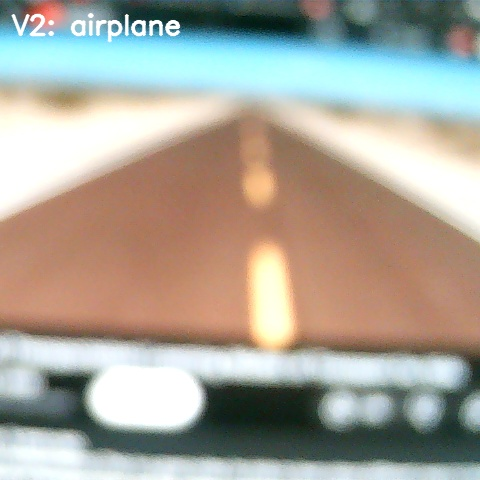

In [8]:
CAMERA_INDEX = None     # None = auto detect 0, then 1
CAMERA_WIDTH = 640
CAMERA_HEIGHT = 480
CAMERA_FPS = 30

# Close an older camera object if this cell is re-run.
try:
    cam.close()
except Exception:
    pass

cam = LatestFrameCamera(
    index=CAMERA_INDEX,
    width=CAMERA_WIDTH,
    height=CAMERA_HEIGHT,
    fps=CAMERA_FPS,
)
print("Camera:", cam.info())

frame, seq = cam.read_latest()
rgb32, crop = center_crop_resize_rgb(frame)

pred, scores, q, inv_q, dt = npu.infer_rgb32(rgb32)
order = np.argsort(scores)[::-1]

print("Prediction:", npu.classes[pred])
print("param 530:", inv_q)
print("Host path: %.2f ms" % (dt*1000.0))
print("Top-3:")
for idx in order[:3]:
    idx = int(idx)
    print("  %-10s %d" % (str(npu.classes[idx]), int(scores[idx])))

view = crop.copy()
cv2.putText(view, "V2: %s" % str(npu.classes[pred]), (12,34),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2, cv2.LINE_AA)
ok, buf = cv2.imencode(".jpg", view)
if ok:
    display(Image(data=buf.tobytes()))


## 6. Live demo

`DISPLAY_EVERY` controls browser rendering load. Inference still runs every loop; only the displayed frames are skipped. Start with `2`.  
`SMOOTHING_WINDOW=5` shows a short majority-vote label to reduce flicker; set it to `1` for raw predictions only.

Live demo started. Interrupt the kernel to stop.


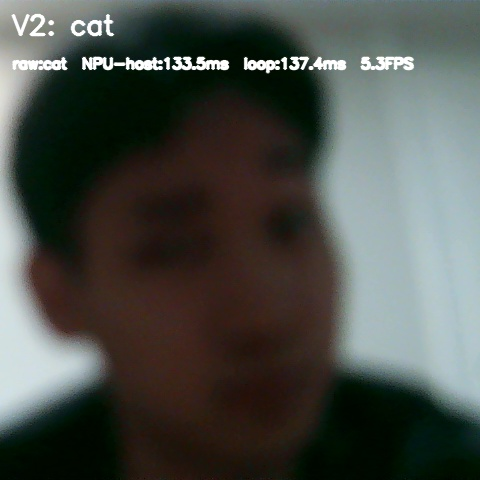

Live demo stopped.


In [9]:
DISPLAY_EVERY = 2
SMOOTHING_WINDOW = 5

history = deque(maxlen=max(1, int(SMOOTHING_WINDOW)))
last_seq = None
frames = 0
fps_window_t0 = time.perf_counter()
shown_fps = 0.0
display_handle = None

print("Live demo started. Interrupt the kernel to stop.")

try:
    while True:
        frame, seq = cam.read_latest(after_seq=last_seq, timeout_s=2.0)
        last_seq = seq

        rgb32, crop = center_crop_resize_rgb(frame)

        t0 = time.perf_counter()
        pred, scores, q, inv_q, npu_s = npu.infer_rgb32(rgb32)
        loop_s = time.perf_counter() - t0

        history.append(pred)
        smooth_pred = Counter(history).most_common(1)[0][0]

        frames += 1
        elapsed = time.perf_counter() - fps_window_t0
        if elapsed >= 1.0:
            shown_fps = frames / elapsed
            frames = 0
            fps_window_t0 = time.perf_counter()

        if (seq % max(1, int(DISPLAY_EVERY))) != 0:
            continue

        view = crop.copy()
        label = str(npu.classes[smooth_pred])
        raw_label = str(npu.classes[pred])

        cv2.putText(view, "V2: %s" % label, (12,34),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    (255,255,255), 2, cv2.LINE_AA)

        cv2.putText(view,
                    "raw:%s  NPU-host:%.1fms  loop:%.1fms  %.1fFPS" %
                    (raw_label, npu_s*1000.0, loop_s*1000.0, shown_fps),
                    (12,68), cv2.FONT_HERSHEY_SIMPLEX, 0.48,
                    (255,255,255), 2, cv2.LINE_AA)

        ok, buf = cv2.imencode(".jpg", view)
        if not ok:
            continue

        img = Image(data=buf.tobytes())
        if display_handle is None:
            display_handle = display(img, display_id=True)
        else:
            display_handle.update(img)

except KeyboardInterrupt:
    print("Live demo stopped.")

except Exception as e:
    print("Live demo error:", repr(e))
    raise
